In [6]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib import colors
import glob

In [7]:
# flist = sorted(glob.glob('/home/oper/Andoya_daily_20260504/*.nc'))
flist = sorted(glob.glob('/data/euliaa-daily/Andoya/L2_20MIN_Andoya_*'))

In [8]:
flist

['/data/euliaa-daily/Andoya/L2_20MIN_Andoya_2025-10-29.nc',
 '/data/euliaa-daily/Andoya/L2_20MIN_Andoya_2025-10-31.nc',
 '/data/euliaa-daily/Andoya/L2_20MIN_Andoya_2025-11-01.nc',
 '/data/euliaa-daily/Andoya/L2_20MIN_Andoya_2025-11-02.nc',
 '/data/euliaa-daily/Andoya/L2_20MIN_Andoya_2025-11-03.nc',
 '/data/euliaa-daily/Andoya/L2_20MIN_Andoya_2025-11-04.nc',
 '/data/euliaa-daily/Andoya/L2_20MIN_Andoya_2025-11-11.nc',
 '/data/euliaa-daily/Andoya/L2_20MIN_Andoya_2025-11-18.nc',
 '/data/euliaa-daily/Andoya/L2_20MIN_Andoya_2025-11-21.nc',
 '/data/euliaa-daily/Andoya/L2_20MIN_Andoya_2025-11-22.nc',
 '/data/euliaa-daily/Andoya/L2_20MIN_Andoya_2025-11-23.nc',
 '/data/euliaa-daily/Andoya/L2_20MIN_Andoya_2025-12-02.nc',
 '/data/euliaa-daily/Andoya/L2_20MIN_Andoya_2025-12-11.nc',
 '/data/euliaa-daily/Andoya/L2_20MIN_Andoya_2025-12-12.nc',
 '/data/euliaa-daily/Andoya/L2_20MIN_Andoya_2026-01-20.nc',
 '/data/euliaa-daily/Andoya/L2_20MIN_Andoya_2026-01-21.nc',
 '/data/euliaa-daily/Andoya/L2_20MIN_And

In [9]:
ds = xr.open_mfdataset(flist[5:12])

In [10]:
ds

<xarray.Dataset> Size: 22MB
Dimensions:                (time: 239, altitude: 867, altitude_mie: 867,
                            line_of_sight: 3, bnds: 2)
Coordinates:
  * altitude               (altitude) float32 3kB 521.0 671.0 ... 1.304e+05
  * time                   (time) datetime64[ns] 2kB 2025-11-04T10:10:00 ... ...
  * altitude_mie           (altitude_mie) float32 3kB 521.0 671.0 ... 1.304e+05
  * line_of_sight          (line_of_sight) int64 24B 0 1 2
Dimensions without coordinates: bnds
Data variables: (12/17)
    u                      (time, altitude) float32 829kB dask.array<chunksize=(1, 867), meta=np.ndarray>
    v                      (time, altitude) float32 829kB dask.array<chunksize=(1, 867), meta=np.ndarray>
    u_flag                 (time, altitude) float64 2MB dask.array<chunksize=(1, 867), meta=np.ndarray>
    v_flag                 (time, altitude) float64 2MB dask.array<chunksize=(1, 867), meta=np.ndarray>
    backscatter_coef       (time, altitude_mie, line_of_sight) float32 2MB dask.array<chunksize=(1, 867, 3), meta=np.ndarray>
    backscatter_coef_flag  (time, altitude_mie, line_of_sight) float64 5MB dask.array<chunksize=(1, 867, 3), meta=np.ndarray>
    ...                     ...
    station_longitude      (time) float64 2kB dask.array<chunksize=(2,), meta=np.ndarray>
    station_altitude       (time) float64 2kB dask.array<chunksize=(2,), meta=np.ndarray>
    range_integration      (time, line_of_sight) float64 6kB dask.array<chunksize=(1, 3), meta=np.ndarray>
    time_integration       (time) float64 2kB dask.array<chunksize=(2,), meta=np.ndarray>
    time_mean              (time) datetime64[ns] 2kB dask.array<chunksize=(2,), meta=np.ndarray>
    time_bnds              (time, bnds) datetime64[ns] 4kB dask.array<chunksize=(1, 2), meta=np.ndarray>
Attributes: (12/33)
    conventions:                            CF-1.8
    campaign_name:                          EULIAA-Andoya
    license:                                Creative Commons Attribution Non ...
    version:                                1.0
    references:                             
    wigos_station_id:                       0-20008-0-ARR
    ...                                     ...
    doi:                                    10.60566/fkvdv-51b32
    processing_date:                        2026-06-25 13:06:06 UTC
    concatenation_history:                  Daily concatenation run by user o...
    station_latitude_unit:                  degrees north
    station_longitude_unit:                 degrees east
    station_altitude_unit:                  meters above sea level

In [11]:
u_masked = ds['u'].where(ds['u_flag'] == 0)

In [12]:
ds.u.to_masked_array()

masked_array(
  data=[[--, --, --, ..., --, --, --],
        [--, --, --, ..., --, --, --],
        [--, --, --, ..., --, --, --],
        ...,
        [--, --, --, ..., --, --, --],
        [--, --, --, ..., --, --, --],
        [--, --, --, ..., --, --, --]],
  mask=[[ True,  True,  True, ...,  True,  True,  True],
        [ True,  True,  True, ...,  True,  True,  True],
        [ True,  True,  True, ...,  True,  True,  True],
        ...,
        [ True,  True,  True, ...,  True,  True,  True],
        [ True,  True,  True, ...,  True,  True,  True],
        [ True,  True,  True, ...,  True,  True,  True]],
  fill_value=np.float64(1e+20),
  dtype=float32)

(np.float64(20413.0), np.float64(20415.0))

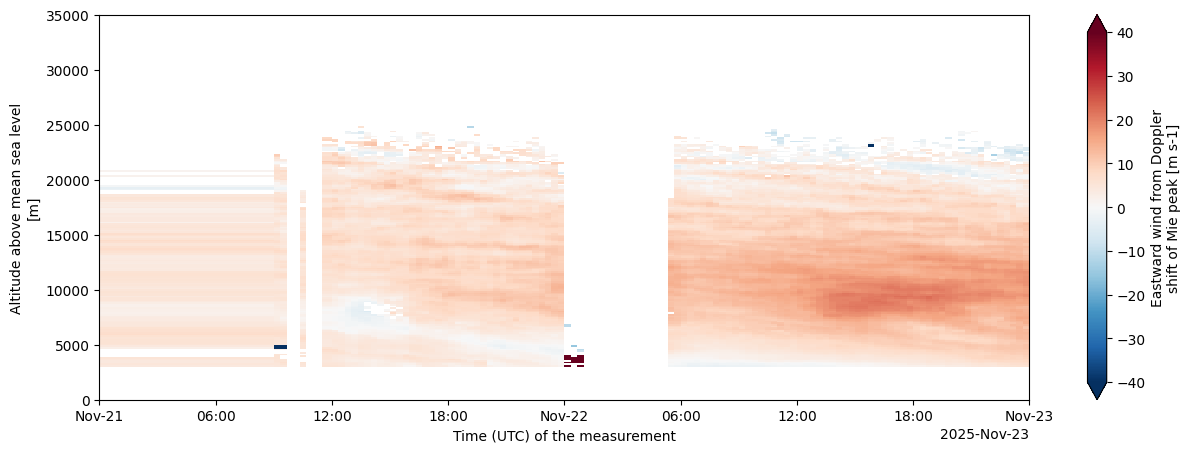

In [13]:
u_masked.plot(x='time',vmin=-40, vmax=40, cmap='RdBu_r', figsize=(15,5))
plt.ylim(0,35000)
plt.xlim(pd.to_datetime('2025-11-21 00:00:00'),pd.to_datetime('2025-11-23 00:00:00'))

In [14]:
ds['u'] = ds['u'].where(ds['u_flag'] == 0)
ds['backscatter_coef'] = ds['backscatter_coef'].where(ds['backscatter_coef_flag'] == 0)

(np.float64(20413.0), np.float64(20415.0))

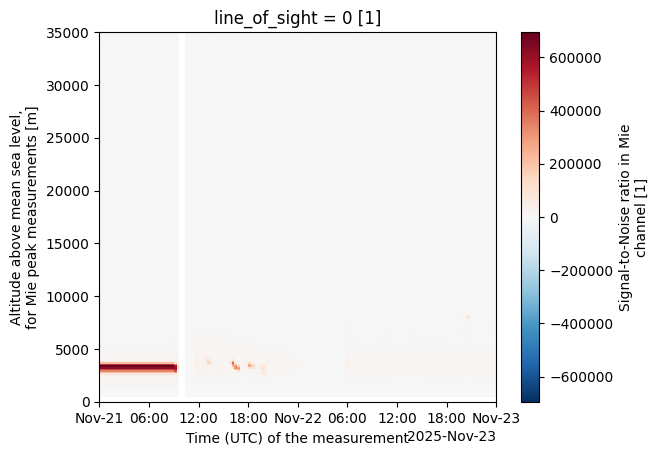

In [15]:
ds.snr_mie.isel(line_of_sight=0).plot(x='time')
plt.ylim(0,35000)
plt.xlim(pd.to_datetime('2025-11-21 00:00:00'),pd.to_datetime('2025-11-23 00:00:00'))

(np.float64(20413.0), np.float64(20415.0))

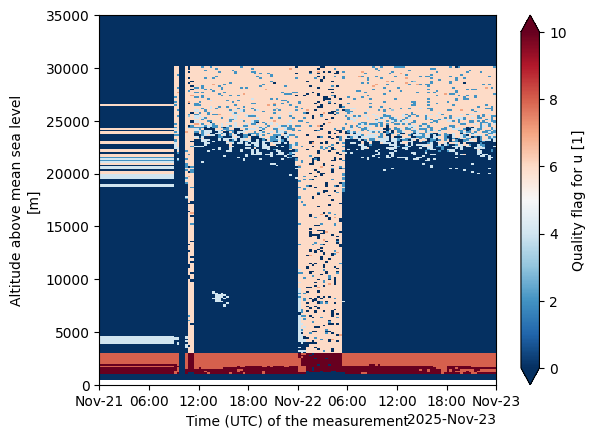

In [16]:
ds.u_flag.plot(x='time',vmin=0,vmax=10,cmap='RdBu_r')
plt.ylim(0,35000)
plt.xlim(pd.to_datetime('2025-11-21 00:00:00'),pd.to_datetime('2025-11-23 00:00:00'))

(np.float64(20413.0), np.float64(20415.0))

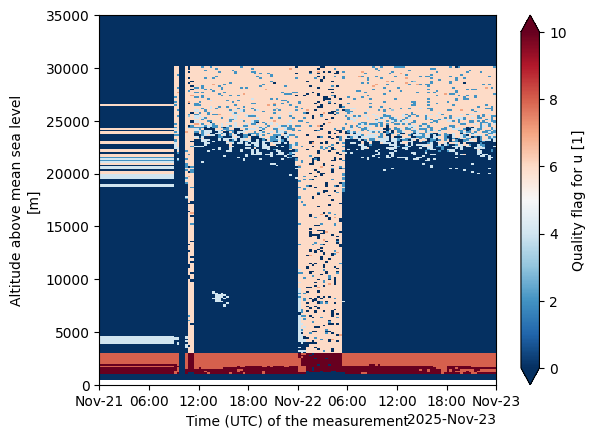

In [17]:
ds.u_flag.plot(x='time',vmin=0,vmax=10,cmap='RdBu_r')
plt.ylim(0,35000)
plt.xlim(pd.to_datetime('2025-11-21 00:00:00'),pd.to_datetime('2025-11-23 00:00:00'))

(np.float64(20413.0), np.float64(20415.0))

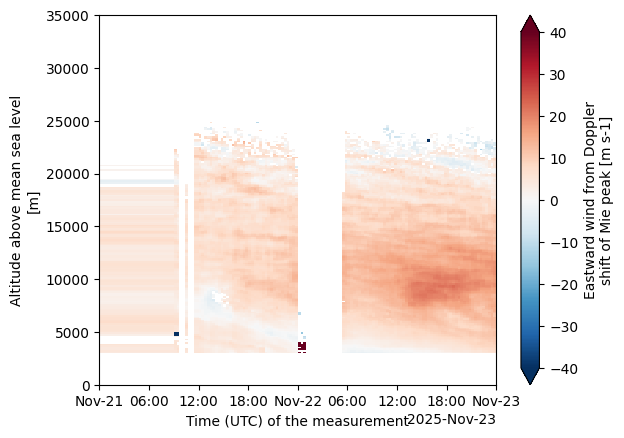

In [18]:
ds.u.plot(x='time',vmin=-40,vmax=40,cmap='RdBu_r')
plt.ylim(0,35000)
plt.xlim(pd.to_datetime('2025-11-21 00:00:00'),pd.to_datetime('2025-11-23 00:00:00'))

(np.float64(20413.0), np.float64(20415.0))

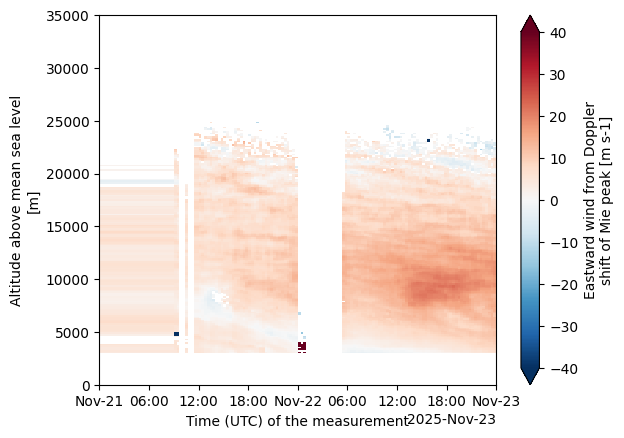

In [19]:
ds.u.plot(x='time',vmin=-40,vmax=40,cmap='RdBu_r')
plt.ylim(0,35000)
plt.xlim(pd.to_datetime('2025-11-21 00:00:00'),pd.to_datetime('2025-11-23 00:00:00'))

(np.float64(20413.0), np.float64(20415.0))

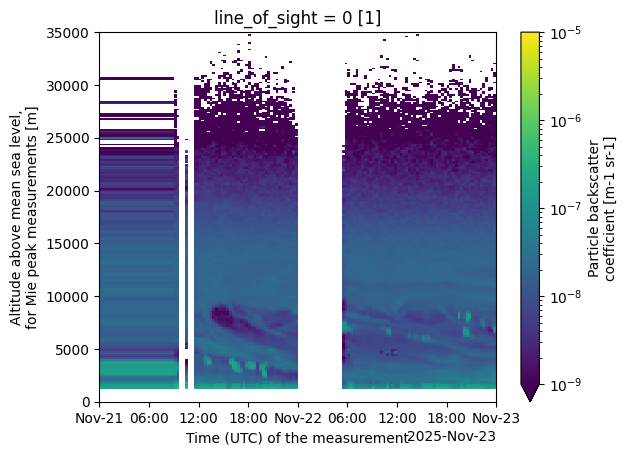

In [20]:
ds.backscatter_coef.isel(line_of_sight=0).plot(x='time',vmin=1e-9,vmax=1e-5,norm=colors.LogNorm(),cmap='viridis')
plt.ylim(0,35000)
plt.xlim(pd.to_datetime('2025-11-21 00:00:00'),pd.to_datetime('2025-11-23 00:00:00'))

(np.float64(20413.0), np.float64(20415.0))

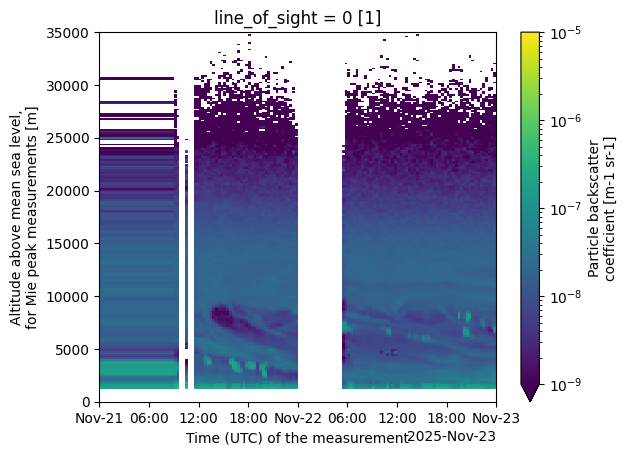

In [21]:
ds.backscatter_coef.isel(line_of_sight=0).plot(x='time',vmin=1e-9,vmax=1e-5,norm=colors.LogNorm(),cmap='viridis')
plt.ylim(0,35000)
plt.xlim(pd.to_datetime('2025-11-21 00:00:00'),pd.to_datetime('2025-11-23 00:00:00'))

In [22]:
u_masked_xr = ds.u.where(ds.u_flag <= 0)
u_masked_xr

<xarray.DataArray 'u' (time: 239, altitude: 867)> Size: 829kB
dask.array<where, shape=(239, 867), dtype=float32, chunksize=(1, 867), chunktype=numpy.ndarray>
Coordinates:
  * altitude  (altitude) float32 3kB 521.0 671.0 821.0 ... 1.303e+05 1.304e+05
  * time      (time) datetime64[ns] 2kB 2025-11-04T10:10:00 ... 2025-12-02T15...
Attributes:
    long_name:          Eastward wind from Doppler shift of Mie peak
    standard_name:      eastward_wind
    units:              m s-1
    scattering_regime:  Mie